# Lab 2 — Classification: Loan Approval Prediction

**Target variable:** `LoanApproved` (binary 0/1)  
**Main metric:** ROC-AUC  
**Dataset:** `train_c.csv` / `test_c.csv`

## 0. Imports & Setup

In [27]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier, GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    confusion_matrix, classification_report
)

import lightgbm as lgb
import xgboost as xgb
from xgboost.callback import EarlyStopping as XGBEarlyStopping
import catboost as cb

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Exploratory Data Analysis (EDA)

In [28]:
df_train_raw = pd.read_csv('train_c.csv')
df_test_raw  = pd.read_csv('test_c.csv')

print('Train shape:', df_train_raw.shape)
print('Test  shape:', df_test_raw.shape)
print(f"NaN LoanApproved: {df_train_raw['LoanApproved'].isna().sum()}")
df_train_raw.head(3)

Train shape: (11017, 35)
Test  shape: (5000, 35)
NaN LoanApproved: 530


,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0


In [29]:
df_train = df_train_raw.dropna(subset=['LoanApproved']).reset_index(drop=True)
print('Train shape:', df_train.shape)
df_train.info()

Train shape: (10487, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10487 entries, 0 to 10486
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtTo

In [30]:
print('Пропуски:')
miss = df_train.isnull().sum().sort_values(ascending=False)
print(miss[miss > 0] if (miss > 0).any() else 'None')
df_train.describe().T.round(2)

Пропуски:
MonthlyDebtPayments       501
LoanAmount                501
CreditScore               501
BaseInterestRate          501
NetWorth                  501
TotalAssets               501
BankruptcyHistory         501
LoanPurpose               501
CheckingAccountBalance    501
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Age,10487.0,39.85,11.61,18.00,32.00,40.00,48.00,80.00
AnnualIncome,10487.0,131587.87,115791.94,15000.00,20959.50,89015.00,257025.00,748508.00
CreditScore,9986.0,678.08,175.19,300.00,550.00,722.50,850.00,850.00
LoanAmount,9986.0,29874.22,27705.51,1063.00,12658.00,21828.50,37158.00,418997.00
LoanDuration,10487.0,53.44,24.49,12.00,36.00,48.00,60.00,120.00
NumberOfDependents,10487.0,1.57,1.42,0.00,0.00,1.00,3.00,6.00
MonthlyDebtPayments,9986.0,546.46,501.98,13.00,233.25,398.00,685.00,10879.00
CreditCardUtilizationRate,10487.0,0.28,0.16,0.00,0.16,0.26,0.39,0.91
NumberOfOpenCreditLines,10487.0,3.03,1.74,0.00,2.00,3.00,4.00,12.00
NumberOfCreditInquiries,10487.0,0.98,0.99,0.00,0.00,1.00,2.00,6.00


### 1.1 Target Variable Distribution

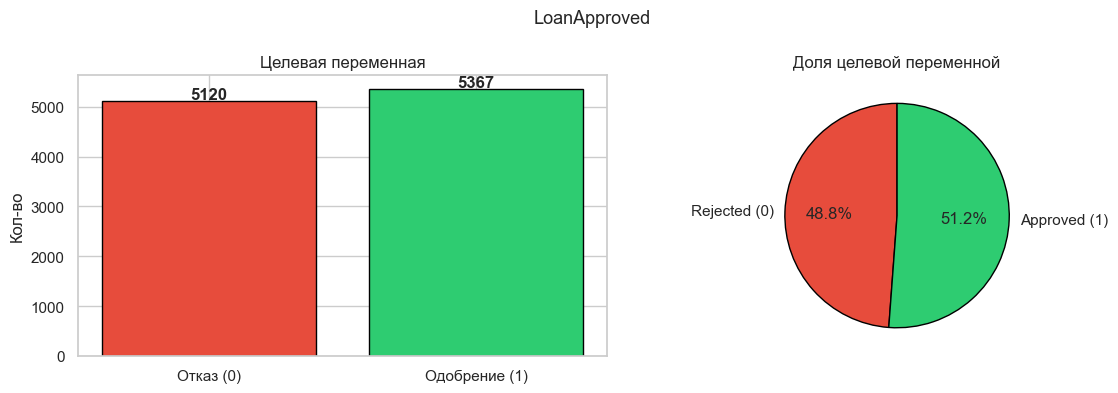

Доля одобрения: 51.2%.


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_train['LoanApproved'].value_counts().sort_index()
axes[0].bar(['Отказ (0)', 'Одобрение (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Целевая переменная')
axes[0].set_ylabel('Кол-во')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Rejected (0)', 'Approved (1)'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, wedgeprops=dict(edgecolor='black'))
axes[1].set_title('Доля целевой переменной')
plt.suptitle('LoanApproved', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Доля одобрения: {counts[1]/len(df_train)*100:.1f}%.')

### Сравнение с числовыми признаками

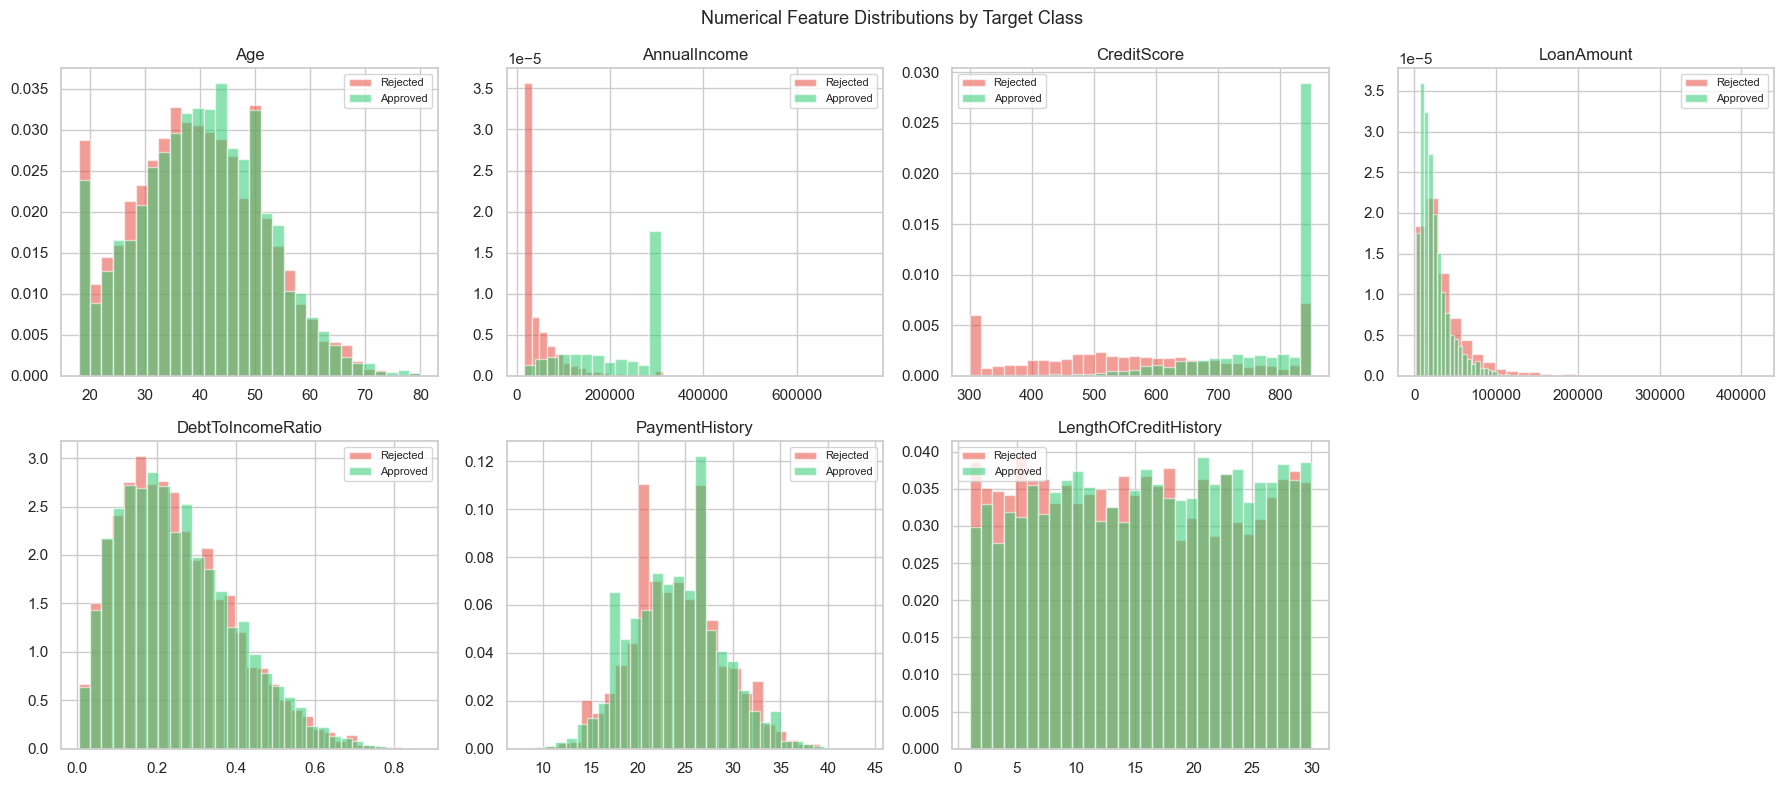

In [32]:
num_plot_cols = ['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount',
                 'DebtToIncomeRatio', 'PaymentHistory', 'LengthOfCreditHistory']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_plot_cols):
    for label, color, lname in [(0, '#e74c3c', 'Rejected'), (1, '#2ecc71', 'Approved')]:
        axes[i].hist(
            df_train.loc[df_train['LoanApproved'] == label, col].dropna(),
            bins=30, alpha=0.55, color=color, label=lname, density=True
        )
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Numerical Feature Distributions by Target Class', fontsize=13)
plt.tight_layout()
plt.show()

### Сравнение с категориальными признаками

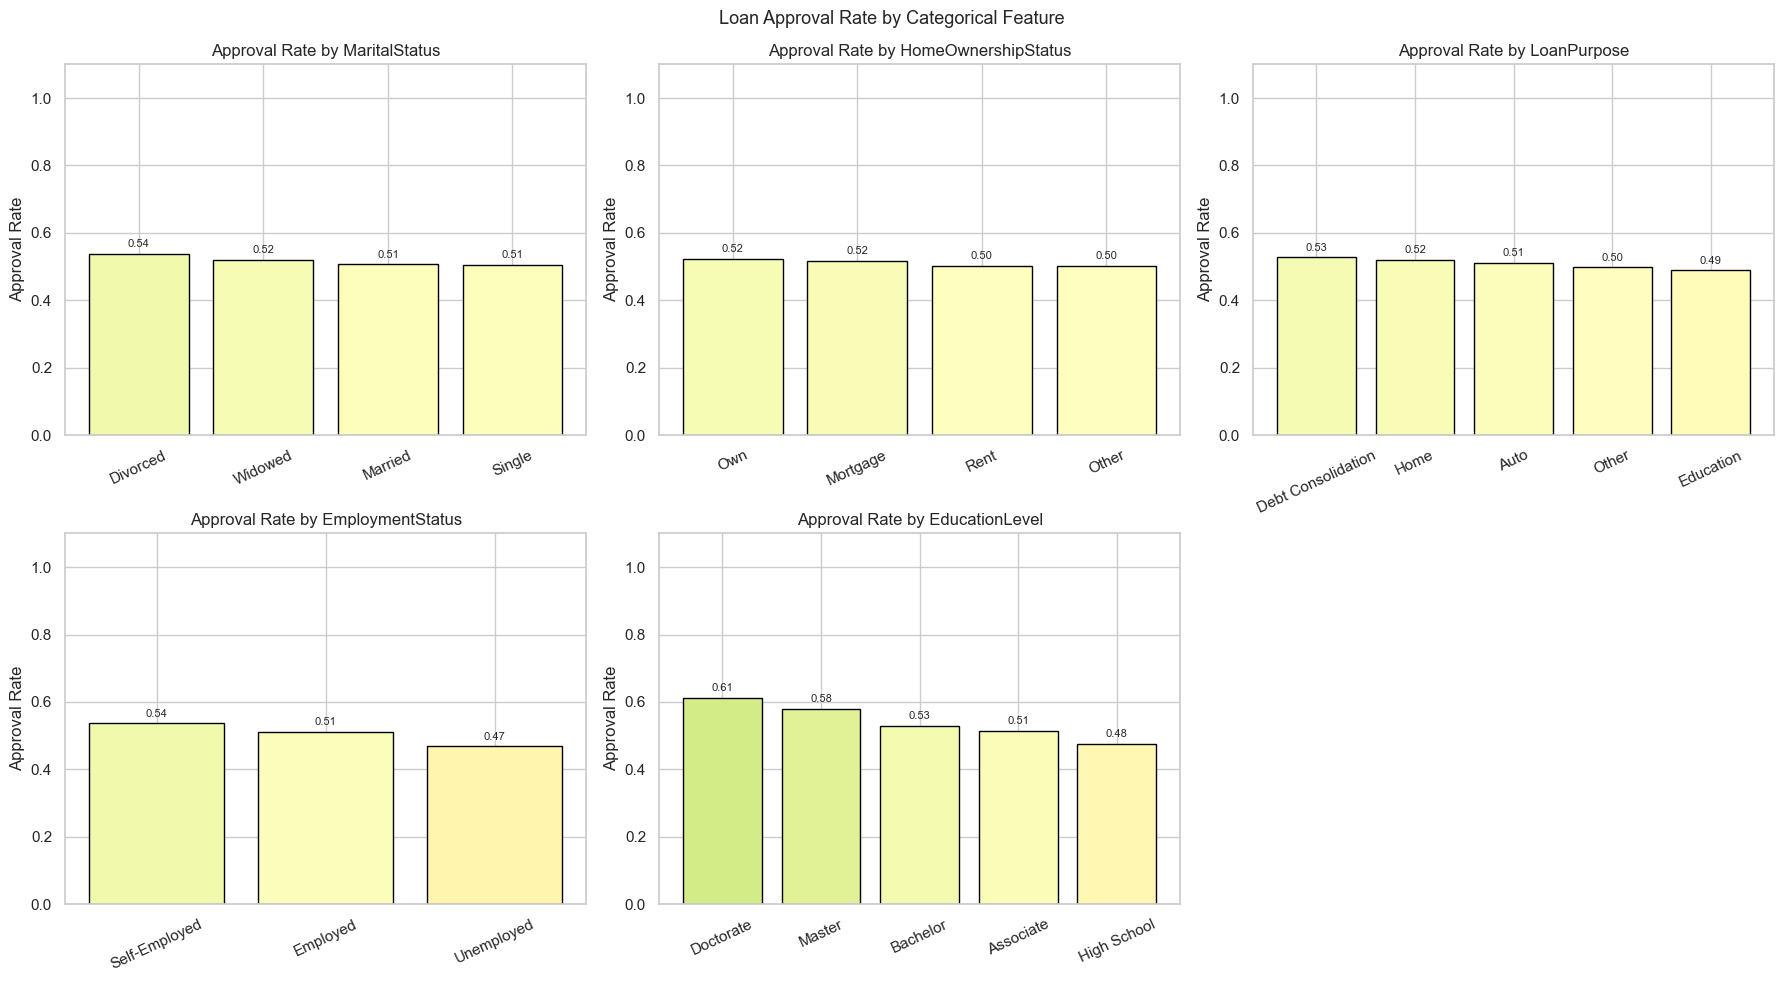

In [33]:
cat_eda_cols = ['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose',
                'EmploymentStatus', 'EducationLevel']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_eda_cols):
    rate = df_train.groupby(col)['LoanApproved'].mean().sort_values(ascending=False)
    bars = axes[i].bar(rate.index, rate.values,
                       color=[plt.cm.RdYlGn(v) for v in rate.values],
                       edgecolor='black')
    axes[i].set_title(f'Approval Rate by {col}')
    axes[i].set_ylabel('Approval Rate')
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].set_ylim(0, 1.1)
    for bar, val in zip(bars, rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                     f'{val:.2f}', ha='center', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Loan Approval Rate by Categorical Feature', fontsize=13)
plt.tight_layout()
plt.show()

### Матрица корреляции

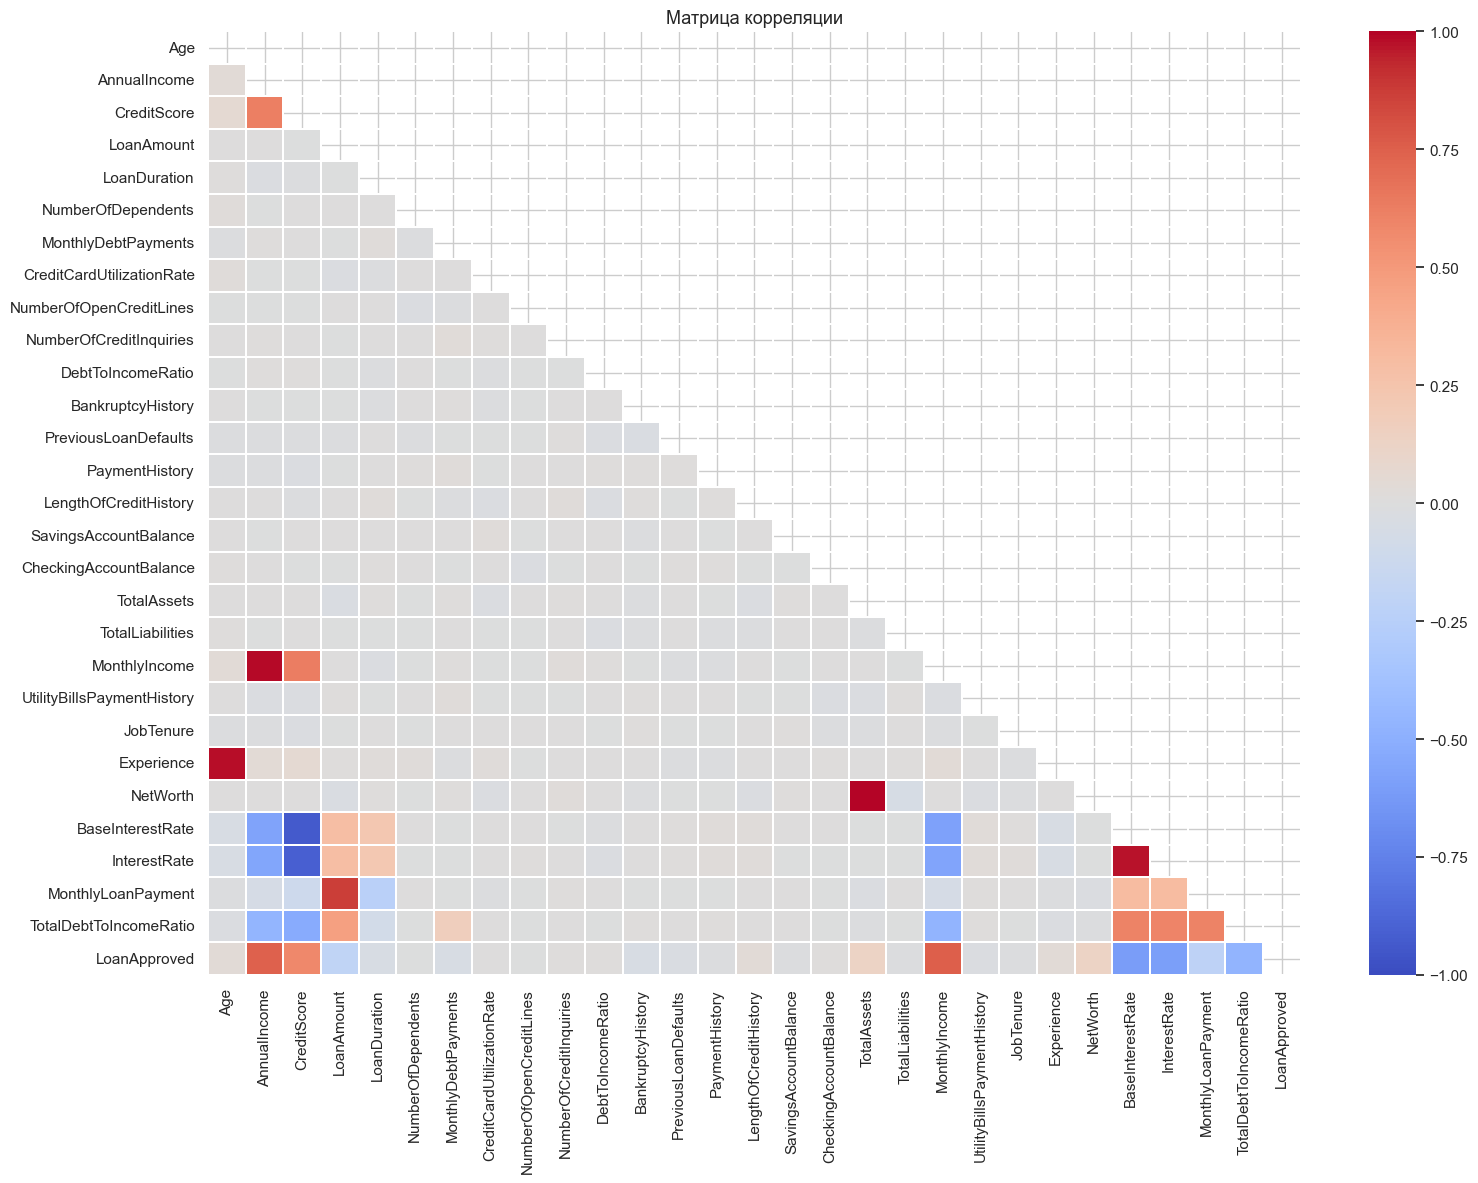

In [35]:
num_df = df_train.select_dtypes(include=[np.number])
corr   = num_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            annot=False, linewidths=0.3)
plt.title('Матрица корреляции', fontsize=13)
plt.tight_layout()
plt.show()

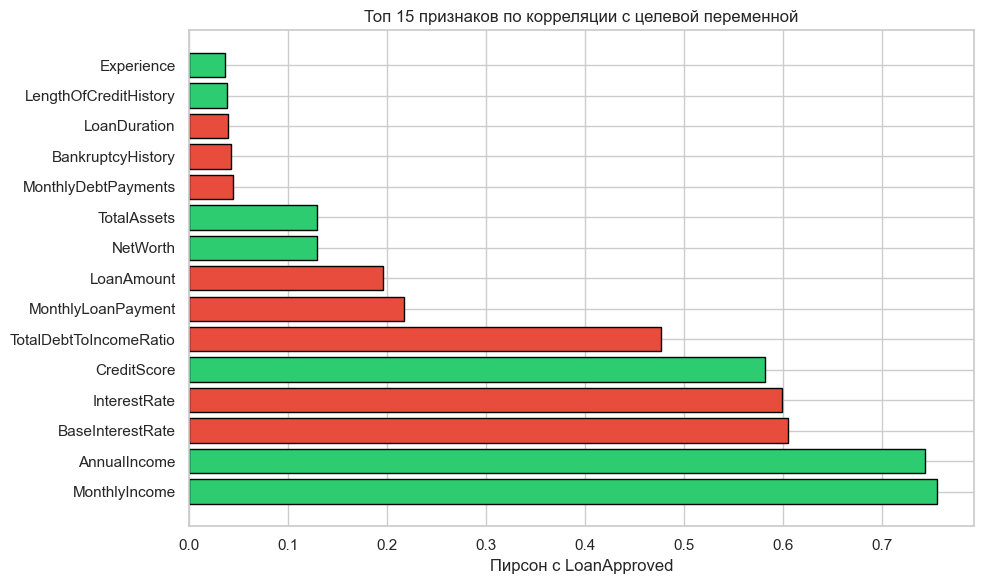

MonthlyIncome             0.7549
AnnualIncome              0.7430
BaseInterestRate         -0.6052
InterestRate             -0.5992
CreditScore               0.5818
TotalDebtToIncomeRatio   -0.4762
MonthlyLoanPayment       -0.2174
LoanAmount               -0.1956
NetWorth                  0.1296
TotalAssets               0.1292
MonthlyDebtPayments      -0.0443
BankruptcyHistory        -0.0422
LoanDuration             -0.0399
LengthOfCreditHistory     0.0385
Experience                0.0367
Name: LoanApproved, dtype: float64


In [36]:
target_corr = corr['LoanApproved'].drop('LoanApproved')
top15 = target_corr.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if target_corr[i] > 0 else '#e74c3c' for i in top15.index]
plt.barh(top15.index, top15.values, color=colors, edgecolor='black')
plt.xlabel('Пирсон с LoanApproved')
plt.title('Топ 15 признаков по корреляции с целевой переменной')
plt.tight_layout()
plt.show()

print(target_corr[top15.index].round(4))

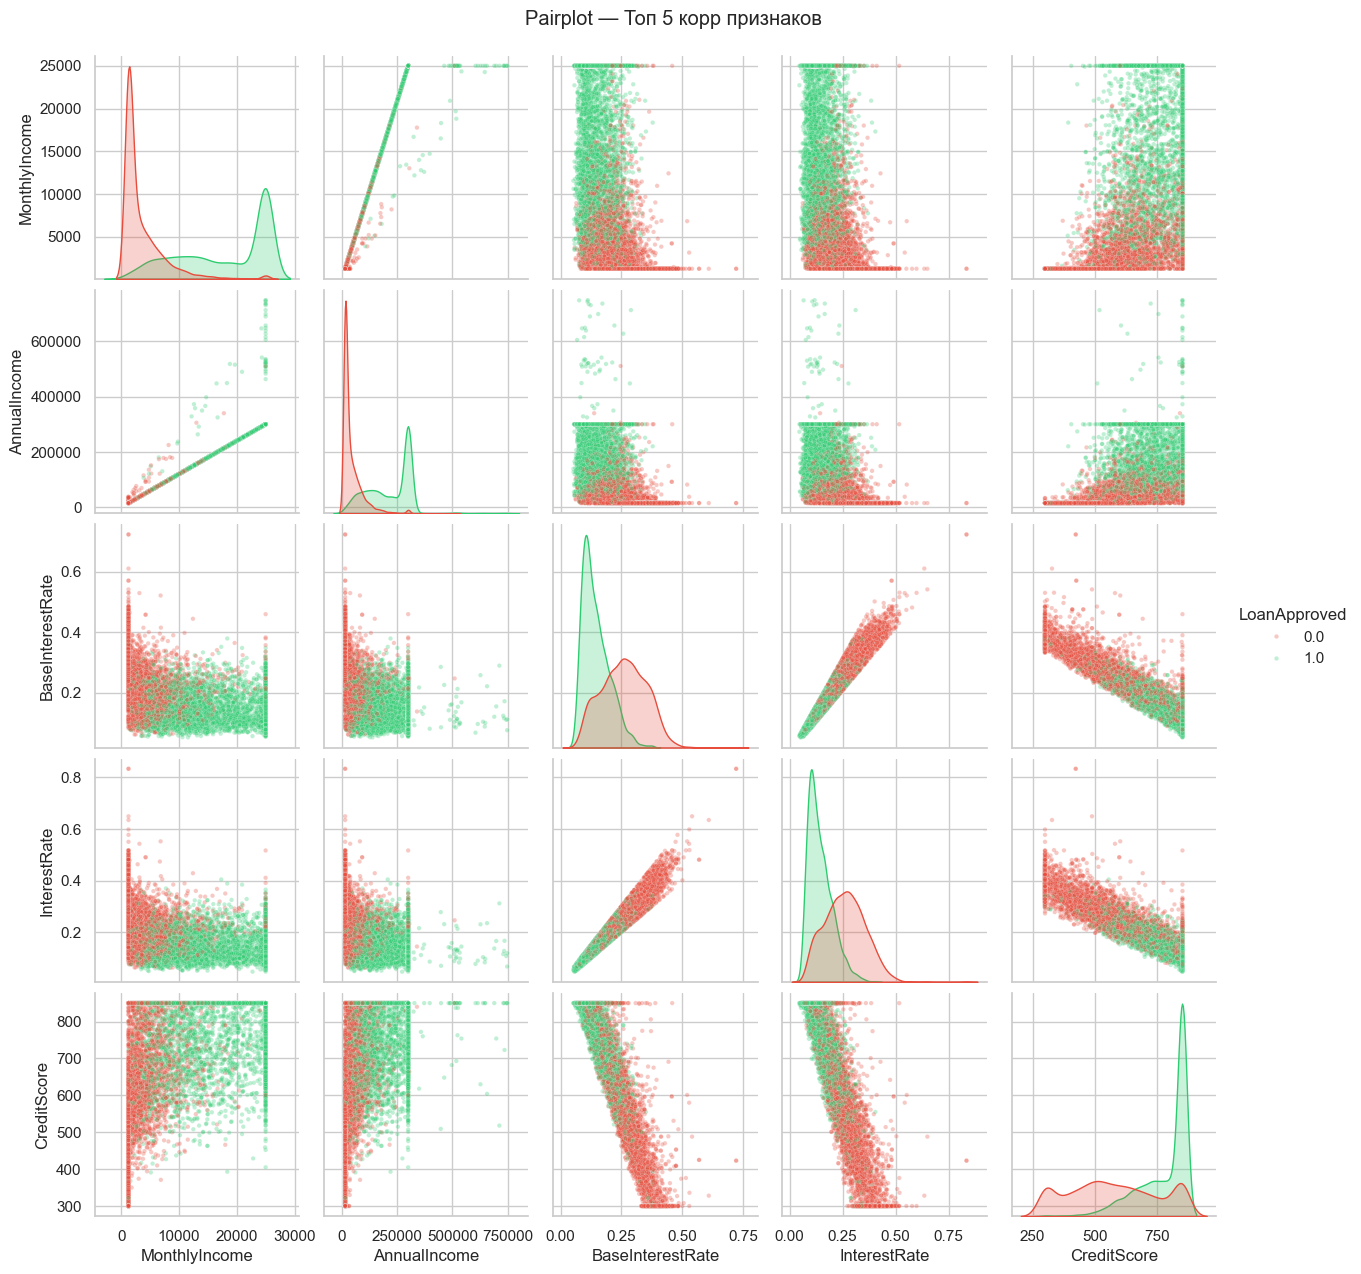

In [37]:
# Pairplot
top5 = top15.index[:5].tolist()
sns.pairplot(
    df_train[top5 + ['LoanApproved']].dropna(),
    hue='LoanApproved',
    palette={0.0: '#e74c3c', 1.0: '#2ecc71'},
    plot_kws={'alpha': 0.3, 's': 10}
)
plt.suptitle('Pairplot — Топ 5 корр признаков', y=1.02)
plt.show()

### 1.5 EDA Conclusions

- **Class balance**: classes are nearly balanced (~51% approved, ~49% rejected), so standard metrics are appropriate.
- **CreditScore** and **PaymentHistory** show the strongest positive correlation with loan approval — higher credit quality → higher approval chance.
- **DebtToIncomeRatio**, **PreviousLoanDefaults**, and **BankruptcyHistory** are negatively correlated — higher debt burden and defaults reduce approval probability.
- **EmploymentStatus** significantly differentiates approval rates; self-employed applicants have lower rates.
- Features like `AnnualIncome`, `MonthlyIncome`, and derived ratios are highly inter-correlated — tree-based models handle this naturally.
- No missing values in the labeled training rows (after dropping the 530 unlabeled rows).

## Обработка данных

In [ ]:
def preprocess(df_train_in, df_test_in, target='LoanApproved'):
    df_tr = df_train_in.copy()
    df_te = df_test_in.copy()

    df_tr = df_tr.dropna(subset=[target]).reset_index(drop=True)

    test_ids = df_te['ID'].values if 'ID' in df_te.columns else np.arange(len(df_te))
    y = df_tr[target].astype(int).values

    df_tr.drop(columns=[target], inplace=True)
    if 'ID' in df_te.columns:
        df_te.drop(columns=['ID'], inplace=True)

    shared_cols = [c for c in df_tr.columns if c in df_te.columns]
    df_tr = df_tr[shared_cols]
    df_te = df_te[shared_cols]

    min_date = pd.to_datetime(df_tr['ApplicationDate'], errors='coerce').min()
    for df in [df_tr, df_te]:
        df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'], errors='coerce')
        df['AppYear']  = df['ApplicationDate'].dt.year
        df['AppMonth'] = df['ApplicationDate'].dt.month
        df['AppDaysSinceMin'] = (df['ApplicationDate'] - min_date).dt.days
        df.drop(columns=['ApplicationDate'], inplace=True)

    for df in [df_tr, df_te]:
        df['Income_per_person']        = df['AnnualIncome'] / (df['NumberOfDependents'] + 1)
        df['Liabilities_to_Income']    = df['TotalLiabilities'] / (df['AnnualIncome'] + 1)
        df['Assets_to_Income']         = df['TotalAssets'] / (df['AnnualIncome'] + 1)
        df['MonthlyDebt_to_Income']    = df['MonthlyDebtPayments'] / (df['MonthlyIncome'] + 1)
        df['MonthlyPayment_to_Income'] = df['MonthlyLoanPayment'] / (df['MonthlyIncome'] + 1)
        df['LoanAmount_to_Income']     = df['LoanAmount'] / (df['AnnualIncome'] + 1)
        df['NetWorth_to_Income']       = df['NetWorth'] / (df['AnnualIncome'] + 1)
        df['TotalDebt_to_Assets']      = df['TotalLiabilities'] / (df['TotalAssets'] + 1)
        df['Interest_Spread']          = df['InterestRate'] - df['BaseInterestRate']
        df['High_CardUtil']            = (df['CreditCardUtilizationRate'] > 0.8).astype(int)
        df['Short_CreditHistory']      = (df['LengthOfCreditHistory'] < 12).astype(int)
        df['Many_Inquiries']           = (df['NumberOfCreditInquiries'] >= 5).astype(int)

    log_cols = ['AnnualIncome', 'LoanAmount', 'TotalAssets', 'TotalLiabilities',
                'NetWorth', 'MonthlyIncome', 'SavingsAccountBalance',
                'CheckingAccountBalance', 'MonthlyDebtPayments']
    for df in [df_tr, df_te]:
        for col in log_cols:
            if col in df.columns:
                df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

    cat_cols = df_tr.select_dtypes(include=['object']).columns.tolist()
    df_tr = pd.get_dummies(df_tr, columns=cat_cols, drop_first=True, dtype=float)
    df_te = pd.get_dummies(df_te, columns=cat_cols, drop_first=True, dtype=float)

    for col in set(df_tr.columns) - set(df_te.columns):
        df_te[col] = 0.0
    df_te = df_te[df_tr.columns]

    clip_cols = [c for c in df_tr.columns if df_tr[c].nunique() > 50]
    for col in clip_cols:
        lo, hi = df_tr[col].quantile(0.01), df_tr[col].quantile(0.99)
        df_tr[col] = df_tr[col].clip(lo, hi)
        df_te[col] = df_te[col].clip(lo, hi)

    feature_names = df_tr.columns.tolist()

    imputer = SimpleImputer(strategy='median')
    X_tr = imputer.fit_transform(df_tr)
    X_te = imputer.transform(df_te)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    return X_tr, y, X_te, test_ids, feature_names


X, y, X_test, test_ids, feature_names = preprocess(df_train_raw, df_test_raw)

print(f'X train : {X.shape}')
print(f'X test  : {X_test.shape}')
print(f'Features: {len(feature_names)}')
print(f'Class counts — 0: {(y==0).sum()}, 1: {(y==1).sum()}')

X train : (10487, 68)
X test  : (5000, 68)
Features: 68
Class counts — 0: 5120, 1: 5367


In [39]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape}  |  Val: {X_val.shape}')

Train: (8389, 68)  |  Val: (2098, 68)


## Кастомные метрики

In [40]:
def my_accuracy(y_true, y_pred):
    "Accuracy = (TP + TN) / N"
    return np.mean(np.asarray(y_true) == np.asarray(y_pred))


def my_precision(y_true, y_pred, zero_division=0.0):
    "Precision = TP / (TP + FP)"
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    return tp / (tp + fp) if (tp + fp) > 0 else zero_division


def my_recall(y_true, y_pred, zero_division=0.0):
    "Recall = TP / (TP + FN)"
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return tp / (tp + fn) if (tp + fn) > 0 else zero_division


def my_f1(y_true, y_pred, zero_division=0.0):
    "F1 = 2 * P * R / (P + R)"
    p = my_precision(y_true, y_pred, zero_division)
    r = my_recall(y_true, y_pred, zero_division)
    return 2 * p * r / (p + r) if (p + r) > 0 else zero_division


def my_roc_auc(y_true, y_score):
    y_true  = np.asarray(y_true,  dtype=float)
    y_score = np.asarray(y_score, dtype=float)

    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    scores_sorted = y_score[order]

    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos

    tp = fp = 0.0
    tpr_pts = [0.0]
    fpr_pts = [0.0]
    prev_score = np.inf

    for i in range(len(y_sorted)):
        if scores_sorted[i] != prev_score and i > 0:
            tpr_pts.append(tp / n_pos)
            fpr_pts.append(fp / n_neg)
        if y_sorted[i] == 1:
            tp += 1
        else:
            fp += 1
        prev_score = scores_sorted[i]

    tpr_pts.append(tp / n_pos)
    fpr_pts.append(fp / n_neg)

    auc_val = sum(
        (fpr_pts[i] - fpr_pts[i-1]) * (tpr_pts[i] + tpr_pts[i-1]) / 2
        for i in range(1, len(fpr_pts))
    )
    return auc_val


def my_pr_auc(y_true, y_score):
    y_true  = np.asarray(y_true,  dtype=float)
    y_score = np.asarray(y_score, dtype=float)

    order = np.argsort(-y_score)
    y_sorted = y_true[order]

    n_pos = y_true.sum()
    tp = fp = 0.0
    prec_pts = [1.0]
    rec_pts  = [0.0]

    for label in y_sorted:
        if label == 1:
            tp += 1
        else:
            fp += 1
        prec_pts.append(tp / (tp + fp))
        rec_pts.append(tp / n_pos)

    auc_val = sum(
        (rec_pts[i] - rec_pts[i-1]) * (prec_pts[i] + prec_pts[i-1]) / 2
        for i in range(1, len(rec_pts))
    )
    return auc_val


print('Кастомные метрики: my_accuracy, my_precision, my_recall, my_f1, my_roc_auc, my_pr_auc')

Кастомные метрики: my_accuracy, my_precision, my_recall, my_f1, my_roc_auc, my_pr_auc


In [43]:
lr = LogisticRegression(max_iter=500, random_state=SEED)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_val)
y_prob_lr = lr.predict_proba(X_val)[:, 1]

pr_arr, re_arr, _ = precision_recall_curve(y_val, y_prob_lr)

rows = [
    ('Accuracy',  my_accuracy(y_val, y_pred_lr),  accuracy_score(y_val, y_pred_lr)),
    ('Precision', my_precision(y_val, y_pred_lr), precision_score(y_val, y_pred_lr)),
    ('Recall',    my_recall(y_val, y_pred_lr),    recall_score(y_val, y_pred_lr)),
    ('F1-score',  my_f1(y_val, y_pred_lr),        f1_score(y_val, y_pred_lr)),
    ('AUC-ROC',   my_roc_auc(y_val, y_prob_lr),   roc_auc_score(y_val, y_prob_lr)),
    ('AUC-PR',    my_pr_auc(y_val, y_prob_lr),    auc(re_arr, pr_arr)),
]

print(f'{"Метрика":<12} {"Кастомная":>10} {"sklearn":>10} {"Разница":>10}')
print('-' * 45)
for name, custom_val, sk_val in rows:
    print(f'{name:<12} {custom_val:>10.6f} {sk_val:>10.6f} {abs(custom_val-sk_val):>10.2e}')

Метрика       Кастомная    sklearn    Разница
---------------------------------------------
Accuracy       0.927550   0.927550   0.00e+00
Precision      0.933271   0.933271   0.00e+00
Recall         0.924581   0.924581   0.00e+00
F1-score       0.928906   0.928906   0.00e+00
AUC-ROC        0.983697   0.983697   8.88e-16
AUC-PR         0.985547   0.985547   9.25e-11


## Кастомный бэг классификатор

In [48]:
import copy

class MyBaggingClassifier:
    """
    Бэггинг (Bagging) для классификации.

    Алгоритм
    Для каждого из n_estimators:
      1. Выбирается случайная подвыборка объектов и признаков.
      2. Обучается базовый классификатор на этой подвыборке.
      3. Сохраняется обученный классификатор и выбранные признаки.

    Параметры
    base_estimator : базовый классификатор
    n_estimators   : количество базовых классификаторов
    max_samples    : доля подвыборки объектов
    max_features   : доля подвыборки признаков
    random_state   : зерно генератора случайных чисел
    """

    def __init__(self, base_estimator=None, n_estimators=10,
                 max_samples=1.0, max_features=1.0, random_state=None):
        self.base_estimator  = base_estimator
        self.n_estimators    = n_estimators
        self.max_samples     = max_samples
        self.max_features    = max_features
        self.random_state    = random_state
        self.estimators_     = []
        self.feature_indices_ = []

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        X, y = np.asarray(X), np.asarray(y)
        n_samples, n_features = X.shape

        n_draw  = max(1, int(self.max_samples  * n_samples))
        n_feats = max(1, int(self.max_features * n_features))

        base = self.base_estimator or DecisionTreeClassifier()
        self.estimators_      = []
        self.feature_indices_ = []

        for _ in range(self.n_estimators):
            sample_idx  = rng.choice(n_samples, size=n_draw, replace=True)
            feature_idx = rng.choice(n_features, size=n_feats, replace=False)

            est = copy.deepcopy(base)
            if hasattr(est, 'random_state'):
                est.random_state = rng.randint(0, 1_000_000)
            est.fit(X[sample_idx][:, feature_idx], y[sample_idx])

            self.estimators_.append(est)
            self.feature_indices_.append(feature_idx)

        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        proba = np.zeros((len(X), 2))
        for est, feat_idx in zip(self.estimators_, self.feature_indices_):
            proba += est.predict_proba(X[:, feat_idx])
        return proba / self.n_estimators

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

In [45]:
BASE_TREE = DecisionTreeClassifier(max_depth=8, random_state=SEED)

my_bag = MyBaggingClassifier(
    base_estimator=BASE_TREE,
    n_estimators=50, max_samples=0.8, max_features=0.8,
    random_state=SEED
)
my_bag.fit(X_train, y_train)
y_pred_my_bag = my_bag.predict(X_val)
y_prob_my_bag = my_bag.predict_proba(X_val)[:, 1]

sk_bag = BaggingClassifier(
    estimator=BASE_TREE,
    n_estimators=50, max_samples=0.8, max_features=0.8,
    random_state=SEED, n_jobs=-1
)
sk_bag.fit(X_train, y_train)
y_pred_sk_bag = sk_bag.predict(X_val)
y_prob_sk_bag = sk_bag.predict_proba(X_val)[:, 1]

print(f'{"Метрика":<12} {"Мой Bagging":>12} {"sklearn Bagging":>16}')
print('-' * 42)
for name, fn, p1, p2 in [
    ('Accuracy',  accuracy_score,  y_pred_my_bag, y_pred_sk_bag),
    ('Precision', precision_score, y_pred_my_bag, y_pred_sk_bag),
    ('Recall',    recall_score,    y_pred_my_bag, y_pred_sk_bag),
    ('F1',        f1_score,        y_pred_my_bag, y_pred_sk_bag),
]:
    print(f'{name:<12} {fn(y_val, p1):>12.4f} {fn(y_val, p2):>16.4f}')
print(f'{"ROC-AUC":<12} {roc_auc_score(y_val, y_prob_my_bag):>12.4f} {roc_auc_score(y_val, y_prob_sk_bag):>16.4f}')

Метрика       Мой Bagging  sklearn Bagging
------------------------------------------
Accuracy           0.9204           0.9247
Precision          0.9187           0.9217
Recall             0.9264           0.9320
F1                 0.9226           0.9269
ROC-AUC            0.9794           0.9793


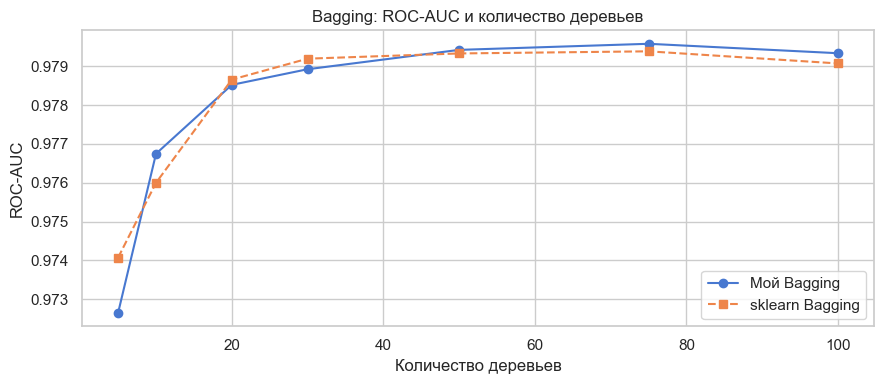

In [47]:
# ROC-AUC и количество деревьев
n_list = [5, 10, 20, 30, 50, 75, 100]
roc_my_bag, roc_sk_bag = [], []

for n in n_list:
    m = MyBaggingClassifier(base_estimator=DecisionTreeClassifier(max_depth=8, random_state=SEED),
                             n_estimators=n, max_samples=0.8, max_features=0.8, random_state=SEED)
    m.fit(X_train, y_train)
    roc_my_bag.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))

    s = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=8, random_state=SEED),
                           n_estimators=n, max_samples=0.8, max_features=0.8,
                           random_state=SEED, n_jobs=-1)
    s.fit(X_train, y_train)
    roc_sk_bag.append(roc_auc_score(y_val, s.predict_proba(X_val)[:, 1]))

plt.figure(figsize=(9, 4))
plt.plot(n_list, roc_my_bag, 'o-', label='Мой Bagging')
plt.plot(n_list, roc_sk_bag, 's--', label='sklearn Bagging')
plt.xlabel('Количество деревьев'); plt.ylabel('ROC-AUC')
plt.title('Bagging: ROC-AUC и количество деревьев')
plt.legend(); plt.tight_layout(); plt.show()

## Кастомный классификатор град бустинга

In [50]:
class MyGradientBoostingClassifier:
    """
    Градиентный Boosting для бинарной классификации (log-loss / cross-entropy).

    Алгоритм
    ---------
    Инициализация F_0 = логарифм шансов среднего значения y.
    Для m = 1 … M:
      1. Вычислить псевдо-остатки: r_i = y_i − σ(F(x_i)).
      2. Подвыборка набора данных.
      3. Обучить неглубокое дерево решений на знаках r_i — это разбиение пространства
         на листья.
      4. Для каждого листа l вычислить обновление Ньютона
             γ_l = Σ r_i / Σ p_i(1−p_i)    (второй порядок / шаг Ньютона)
      5. Обновить F ← F + η · γ_{leaf(x)}.

    Параметры
    ----------
    n_estimators     : количество раундов бустинга
    learning_rate    : коэффициент сжатия η
    max_depth        : глубина базовых деревьев
    min_samples_split: минимальное количество образцов для разбиения
    subsample        : доля подвыборки строк за раунд
    random_state     : зерно генератора случайных чисел
    """

    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3,
                 min_samples_split=2, subsample=1.0, random_state=None):
        self.n_estimators      = n_estimators
        self.learning_rate     = learning_rate
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.subsample         = subsample
        self.random_state      = random_state
        self.trees_            = []
        self.F0_               = 0.0

    @staticmethod
    def _sigmoid(x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        X, y = np.asarray(X, dtype=float), np.asarray(y, dtype=float)
        n = len(y)

        p0 = np.clip(y.mean(), 1e-7, 1 - 1e-7)
        self.F0_ = np.log(p0 / (1 - p0))
        F = np.full(n, self.F0_)

        self.trees_ = []
        n_sub = max(1, int(self.subsample * n))

        for _ in range(self.n_estimators):
            p = self._sigmoid(F)
            residuals = y - p

            idx = rng.choice(n, size=n_sub, replace=False)

            # Бинаризация знаков остатка для критерия разбиения дерева
            res_sign = (residuals[idx] > 0).astype(int)
            # Защита: убедитесь, что есть как минимум 2 класса, чтобы дерево могло разделиться
            if len(np.unique(res_sign)) < 2:
                res_sign[0] = 1 - res_sign[0]

            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                random_state=rng.randint(0, 1_000_000)
            )
            tree.fit(X[idx], res_sign)

            # значения листьев по шагу Ньютона с использованием полных остатков
            leaf_ids = tree.apply(X)
            gamma    = np.zeros(tree.tree_.node_count)
            for leaf in np.unique(leaf_ids):
                mask = leaf_ids == leaf
                num  = residuals[mask].sum()
                den  = (p[mask] * (1 - p[mask])).sum() + 1e-8
                gamma[leaf] = num / den

            F += self.learning_rate * gamma[leaf_ids]
            self.trees_.append((tree, gamma))

        return self

    def _decision_function(self, X):
        X = np.asarray(X, dtype=float)
        F = np.full(len(X), self.F0_)
        for tree, gamma in self.trees_:
            F += self.learning_rate * gamma[tree.apply(X)]
        return F

    def predict_proba(self, X):
        p = self._sigmoid(self._decision_function(X))
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

In [51]:
my_gb = MyGradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    subsample=0.8, random_state=SEED
)
my_gb.fit(X_train, y_train)
y_pred_my_gb = my_gb.predict(X_val)
y_prob_my_gb = my_gb.predict_proba(X_val)[:, 1]

sk_gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    subsample=0.8, random_state=SEED
)
sk_gb.fit(X_train, y_train)
y_pred_sk_gb = sk_gb.predict(X_val)
y_prob_sk_gb = sk_gb.predict_proba(X_val)[:, 1]

print(f'{"Метрика":<12} {"My GBM":>10} {"sklearn GBM":>13}')
print('-' * 38)
for name, fn, p1, p2 in [
    ('Accuracy',  accuracy_score,  y_pred_my_gb, y_pred_sk_gb),
    ('Precision', precision_score, y_pred_my_gb, y_pred_sk_gb),
    ('Recall',    recall_score,    y_pred_my_gb, y_pred_sk_gb),
    ('F1',        f1_score,        y_pred_my_gb, y_pred_sk_gb),
]:
    print(f'{name:<12} {fn(y_val, p1):>10.4f} {fn(y_val, p2):>13.4f}')
print(f'{"ROC-AUC":<12} {roc_auc_score(y_val, y_prob_my_gb):>10.4f} {roc_auc_score(y_val, y_prob_sk_gb):>13.4f}')

Метрика          My GBM   sklearn GBM
--------------------------------------
Accuracy         0.9090        0.9256
Precision        0.9099        0.9266
Recall           0.9125        0.9283
F1               0.9112        0.9274
ROC-AUC          0.9642        0.9822


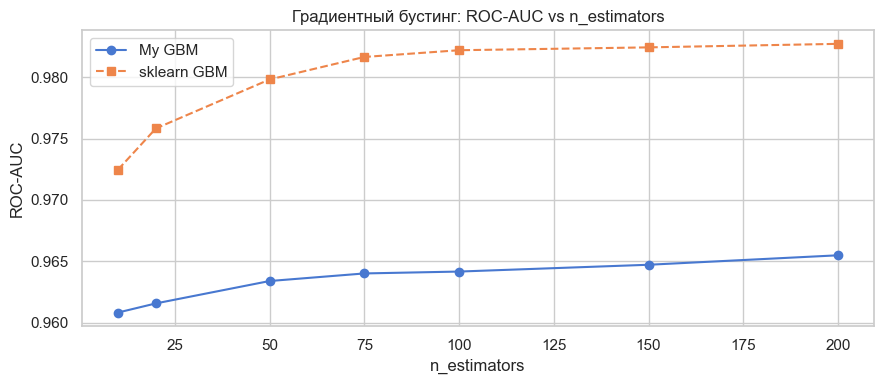

In [52]:
# Конвергенция: ROC-AUC vs n_estimators
n_list_gb = [10, 20, 50, 75, 100, 150, 200]
roc_my_gb, roc_sk_gb = [], []

for n in n_list_gb:
    m = MyGradientBoostingClassifier(n_estimators=n, learning_rate=0.1,
                                      max_depth=3, subsample=0.8, random_state=SEED)
    m.fit(X_train, y_train)
    roc_my_gb.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))

    s = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1,
                                   max_depth=3, subsample=0.8, random_state=SEED)
    s.fit(X_train, y_train)
    roc_sk_gb.append(roc_auc_score(y_val, s.predict_proba(X_val)[:, 1]))

plt.figure(figsize=(9, 4))
plt.plot(n_list_gb, roc_my_gb, 'o-', label='My GBM')
plt.plot(n_list_gb, roc_sk_gb, 's--', label='sklearn GBM')
plt.xlabel('n_estimators'); plt.ylabel('ROC-AUC')
plt.title('Градиентный бустинг: ROC-AUC vs n_estimators')
plt.legend(); plt.tight_layout(); plt.show()

## Сравнение библиотек

In [54]:
sk_gb_cmp = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    subsample=0.8, random_state=SEED
)
sk_gb_cmp.fit(X_train, y_train)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, verbose=-1
)
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(-1)
    ]
)

xgb_model = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='auc',
    random_state=SEED, verbosity=0,
    callbacks=[XGBEarlyStopping(rounds=30, save_best=True)]
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

cat_model = cb.CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    subsample=0.8, eval_metric='AUC',
    early_stopping_rounds=30,
    random_seed=SEED, verbose=False
)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)

CatBoostClassifier(depth=6, early_stopping_rounds=30, eval_metric='AUC', iterations=500, learning_rate=0.05, random_seed=42, subsample=0.8, verbose=False)

In [55]:
models_cmp = {
    'sklearn GBM': sk_gb_cmp,
    'LightGBM':    lgbm_model,
    'XGBoost':     xgb_model,
    'CatBoost':    cat_model,
}

results = {}
print(f'{"Модель":<15} {"Accuracy":>10} {"Precision":>10} {"Recall":>8} {"F1":>8} {"ROC-AUC":>10}')
print('-' * 65)
for name, model in models_cmp.items():
    yp = model.predict(X_val)
    ys = model.predict_proba(X_val)[:, 1]
    r  = dict(acc=accuracy_score(y_val,yp), prec=precision_score(y_val,yp),
              rec=recall_score(y_val,yp),   f1=f1_score(y_val,yp),
              roc=roc_auc_score(y_val,ys),  proba=ys)
    results[name] = r
    print(f'{name:<15} {r["acc"]:>10.4f} {r["prec"]:>10.4f} {r["rec"]:>8.4f} '
          f'{r["f1"]:>8.4f} {r["roc"]:>10.4f}')

best_lib = max(results, key=lambda k: results[k]['roc'])
print(f'\nЛучшая модель по ROC-AUC: {best_lib} ({results[best_lib]["roc"]:.4f})')

Модель            Accuracy  Precision   Recall       F1    ROC-AUC
-----------------------------------------------------------------
sklearn GBM         0.9295     0.9256   0.9376   0.9315     0.9834
LightGBM            0.9276     0.9269   0.9320   0.9294     0.9835
XGBoost             0.9304     0.9304   0.9339   0.9322     0.9842
CatBoost            0.9337     0.9365   0.9339   0.9352     0.9844

Лучшая модель по ROC-AUC: CatBoost (0.9844)


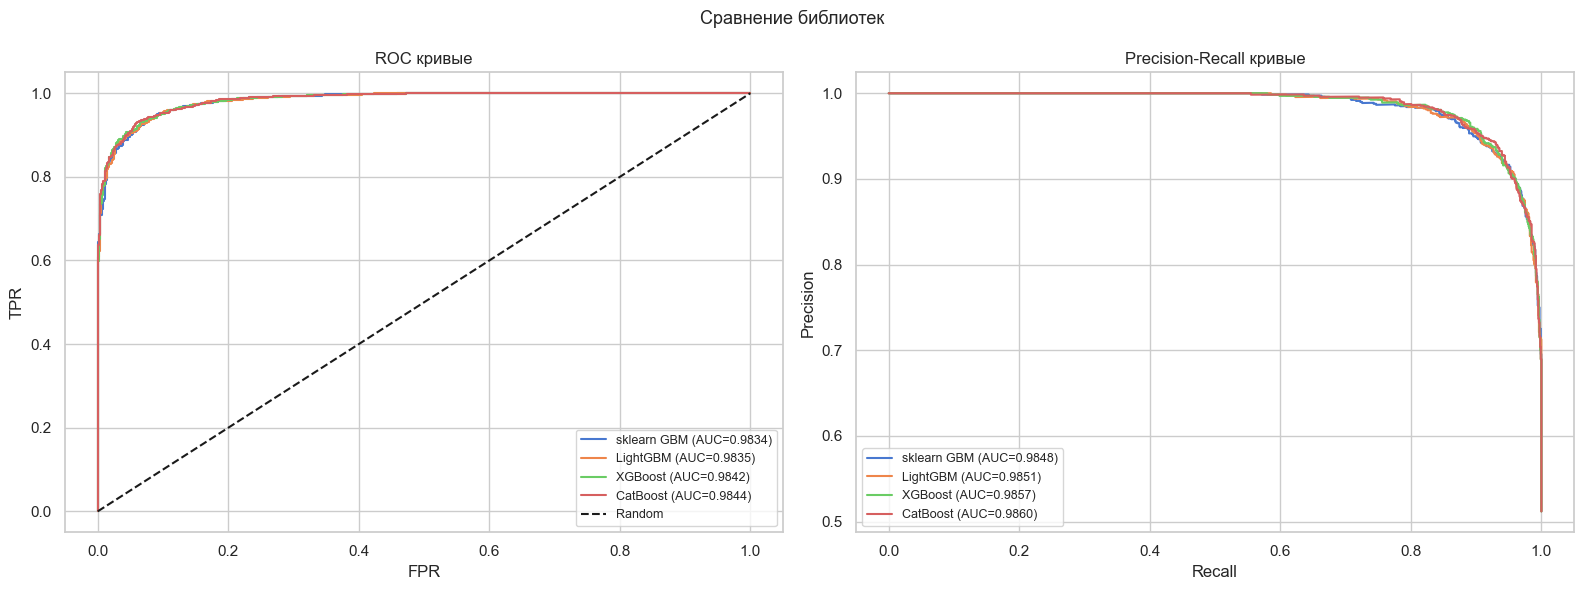

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC кривые
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_val, res['proba'])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={res["roc"]:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC кривые'); axes[0].legend(fontsize=9)

# PR кривые
for name, res in results.items():
    pr_c, re_c, _ = precision_recall_curve(y_val, res['proba'])
    pr_auc_val = auc(re_c, pr_c)
    axes[1].plot(re_c, pr_c, label=f'{name} (AUC={pr_auc_val:.4f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall кривые'); axes[1].legend(fontsize=9)

plt.suptitle('Сравнение библиотек', fontsize=13)
plt.tight_layout()
plt.show()

## Оптимизация гиперпараметров с помощью Optuna

In [57]:
print(f'Оптимизация гиперпараметров для: {best_lib}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int  ('n_estimators',     100, 1000),
        learning_rate    = trial.suggest_float('learning_rate',    0.005, 0.3, log=True),
        max_depth        = trial.suggest_int  ('max_depth',        3, 9),
        num_leaves       = trial.suggest_int  ('num_leaves',       15, 255),
        subsample        = trial.suggest_float('subsample',        0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha',        1e-8, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda',       1e-8, 10.0, log=True),
        min_child_samples= trial.suggest_int  ('min_child_samples',5, 100),
        random_state     = SEED,
        verbose          = -1,
    )
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f'\nЛучший CV ROC-AUC: {study.best_value:.4f}')
print('Лучшие параметры:')
for k, v in study.best_params.items():
    print(f'  {k:25s}: {v}')

Оптимизация гиперпараметров для: CatBoost


Best trial: 12. Best value: 0.985891: 100%|██████████| 60/60 [02:18<00:00,  2.31s/it]


Лучший CV ROC-AUC: 0.9859
Лучшие параметры:
  n_estimators             : 232
  learning_rate            : 0.057781466148555255
  max_depth                : 5
  num_leaves               : 18
  subsample                : 0.7566297445510356
  colsample_bytree         : 0.6654829885487549
  reg_alpha                : 0.06799055770271313
  reg_lambda               : 0.0023771409498024904
  min_child_samples        : 5


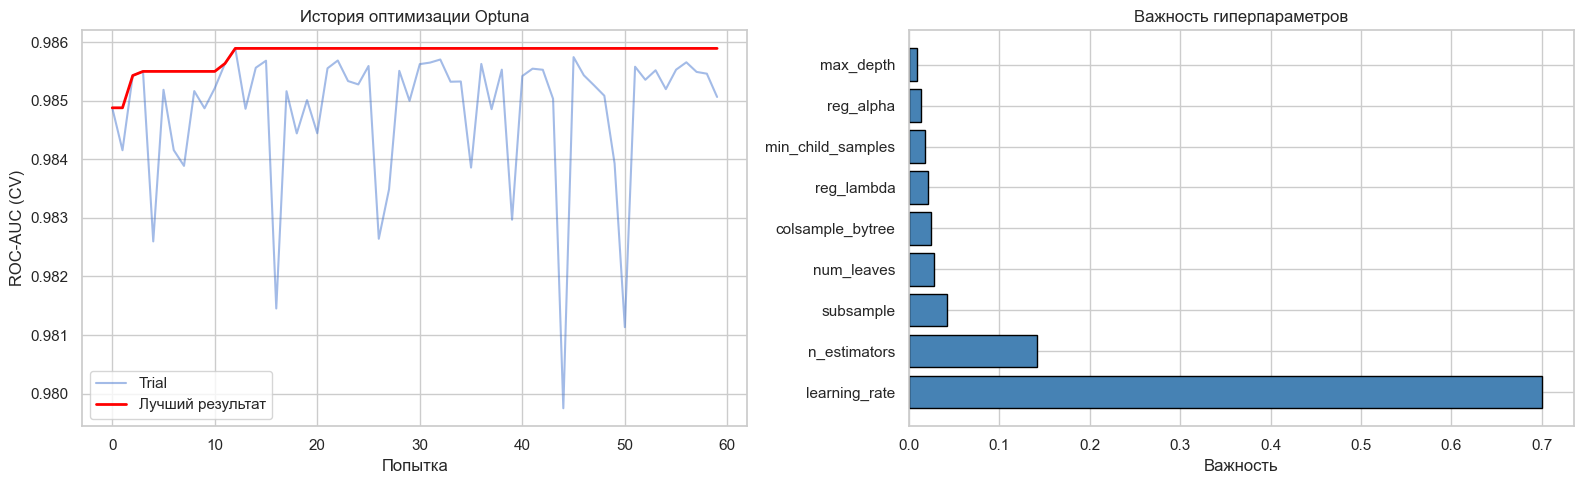

In [58]:
# История оптимизации
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

trials_df = study.trials_dataframe()
axes[0].plot(trials_df.index, trials_df['value'], alpha=0.5, label='Trial')
axes[0].plot(trials_df.index,
             trials_df['value'].cummax(), color='red', lw=2, label='Лучший результат')
axes[0].set_xlabel('Попытка'); axes[0].set_ylabel('ROC-AUC (CV)')
axes[0].set_title('История оптимизации Optuna')
axes[0].legend()

# Важность гиперпараметров
try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()),
                 color='steelblue', edgecolor='black')
    axes[1].set_xlabel('Важность')
    axes[1].set_title('Важность гиперпараметров')
except Exception as e:
    axes[1].text(0.5, 0.5, str(e), ha='center', va='center')

plt.tight_layout()
plt.show()

In [59]:
# Обучение лучшей модели на тренировочном наборе и оценка на валидационном наборе
best_params = {**study.best_params, 'random_state': SEED, 'verbose': -1}

best_model = lgb.LGBMClassifier(**best_params)
best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_val)
y_prob_best = best_model.predict_proba(X_val)[:, 1]

pr_c, re_c, _ = precision_recall_curve(y_val, y_prob_best)

print('Настроенный LightGBM — Валидация')
print(f'{"Метрика":<12} {"Собственная":>10} {"sklearn":>10}')
rows_best = [
    ('Accuracy',  my_accuracy(y_val, y_pred_best),  accuracy_score(y_val, y_pred_best)),
    ('Precision', my_precision(y_val, y_pred_best), precision_score(y_val, y_pred_best)),
    ('Recall',    my_recall(y_val, y_pred_best),    recall_score(y_val, y_pred_best)),
    ('F1-score',  my_f1(y_val, y_pred_best),        f1_score(y_val, y_pred_best)),
    ('AUC-ROC',   my_roc_auc(y_val, y_prob_best),   roc_auc_score(y_val, y_prob_best)),
    ('AUC-PR',    my_pr_auc(y_val, y_prob_best),    auc(re_c, pr_c)),
]
for name, cv_val, sk_val in rows_best:
    print(f'{name:<12} {cv_val:>10.4f} {sk_val:>10.4f}')

Настроенный LightGBM — Валидация
Метрика      Собственная    sklearn
Accuracy         0.9276     0.9276
Precision        0.9276     0.9276
Recall           0.9311     0.9311
F1-score         0.9294     0.9294
AUC-ROC          0.9833     0.9833
AUC-PR           0.9850     0.9850


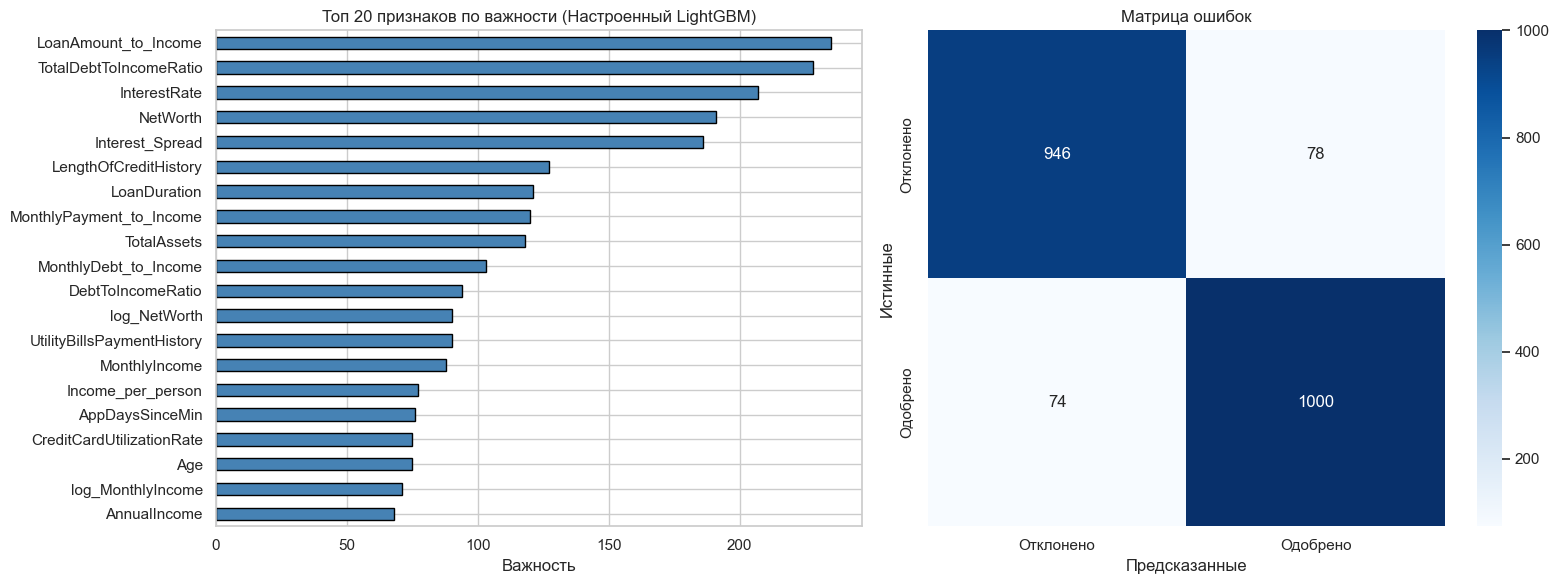

              precision    recall  f1-score   support

   Отклонено       0.93      0.92      0.93      1024
    Одобрено       0.93      0.93      0.93      1074

    accuracy                           0.93      2098
   macro avg       0.93      0.93      0.93      2098
weighted avg       0.93      0.93      0.93      2098



In [60]:
# Важность признаков
feat_imp = pd.Series(best_model.feature_importances_, index=feature_names).nlargest(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_imp.sort_values().plot(kind='barh', color='steelblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Топ 20 признаков по важности (Настроенный LightGBM)')
axes[0].set_xlabel('Важность')

# Матрица ошибок
cm = confusion_matrix(y_val, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Отклонено', 'Одобрено'],
            yticklabels=['Отклонено', 'Одобрено'], ax=axes[1])
axes[1].set_title('Матрица ошибок'); axes[1].set_ylabel('Истинные'); axes[1].set_xlabel('Предсказанные')

plt.tight_layout(); plt.show()

print(classification_report(y_val, y_pred_best, target_names=['Отклонено', 'Одобрено']))

## Финалочка

In [61]:
final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X, y)

test_proba = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({'ID': test_ids, 'LoanApproved': test_proba})
submission.to_csv('submission_c.csv', index=False)

print('Сохранено в: submission_c.csv')
print(f'Количество: {submission.shape}')
print(f'Статистика вероятностей:\n{submission["LoanApproved"].describe().round(4)}')

Сохранено в: submission_c.csv
Количество: (5000, 2)
Статистика вероятностей:
count    5000.0000
mean        0.5193
std         0.4551
min         0.0001
25%         0.0040
50%         0.6212
75%         0.9961
max         1.0000
Name: LoanApproved, dtype: float64


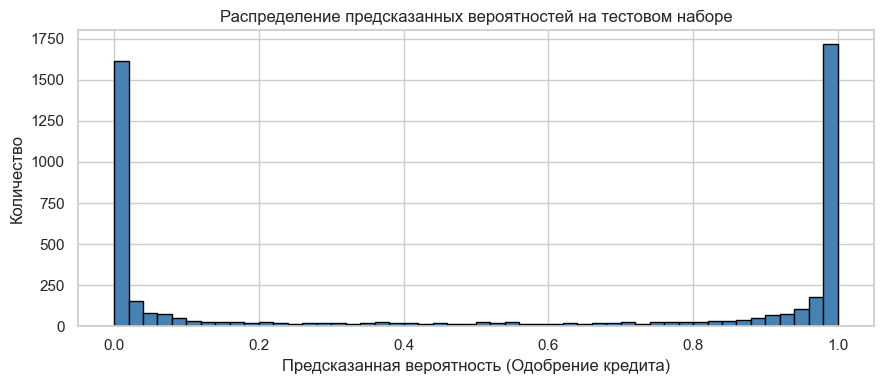

,ID,LoanApproved
0,0,0.991492
1,1,0.002937
2,2,0.999455
3,3,0.998574
4,4,0.997530
5,5,0.001796
6,6,0.999671
7,7,0.997514
8,8,0.694554
9,9,0.001259


In [62]:
plt.figure(figsize=(9, 4))
plt.hist(test_proba, bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Предсказанная вероятность (Одобрение кредита)')
plt.ylabel('Количество')
plt.title('Распределение предсказанных вероятностей на тестовом наборе')
plt.tight_layout()
plt.show()

submission.head(10)